# Known TF binding sites from RegulonDB

Load `regulonDatamart.bson` (RegulonDB 14 datamart export) and flatten it into a table of every known transcription-factor binding site: which TF binds it, the RegulonDB evidence tier (Confirmed / Strong / Weak) backing that regulatory interaction, and the binding site's genomic location.

In [1]:
import pandas as pd
from bson import decode_file_iter

ROOT = "../../data/regulonDB_14"

In [2]:
def bson_to_dataframe(path, max_docs=None):
    """
    Load a BSON file (concatenated BSON documents) into a pandas DataFrame.

    Parameters
    ----------
    path : str
        Path to .bson file
    max_docs : int or None
        Optional cap on number of documents to load (useful for debugging)

    Returns
    -------
    pandas.DataFrame
        One row per BSON document, keys become columns
    """
    records = []
    with open(path, "rb") as f:
        for i, doc in enumerate(decode_file_iter(f)):
            records.append(doc)
            if max_docs is not None and i + 1 >= max_docs:
                break

    return pd.DataFrame(records)

In [3]:
df_regulon = bson_to_dataframe(ROOT + "/regulondbdatamarts/regulonDatamart.bson")
df_regulon.shape

(290, 8)

Each row of `df_regulon` is one regulator. Its `regulatoryInteractions` column holds a list of regulatory interactions for that regulator; each interaction carries a `confidenceLevel` (RegulonDB evidence tier: `C` = Confirmed, `S` = Strong, `W` = Weak) and, when the interaction is mediated by a classic TF binding site rather than e.g. a riboswitch/small-RNA mechanism, a `regulatoryBindingSites` record with the site's genomic coordinates.

In [4]:
CONFIDENCE_LEVELS = {"C": "Confirmed", "S": "Strong", "W": "Weak"}

rows = []
for _, regulator in df_regulon.iterrows():
    for interaction in regulator["regulatoryInteractions"]:
        binding_site = interaction.get("regulatoryBindingSites")
        if not binding_site:
            continue
        rows.append({
            "binding_site_id": binding_site.get("_id"),
            "tf_id": regulator["regulator"].get("_id"),
            "tf_name": regulator["regulator"].get("name"),
            "tf_abbreviated_name": regulator["regulator"].get("abbreviatedName"),
            "tf_type": regulator["regulator"].get("type"),
            "regulated_entity": interaction.get("regulatedEntity", {}).get("name"),
            "function": interaction.get("function"),
            "evidence_tier": CONFIDENCE_LEVELS.get(interaction.get("confidenceLevel")),
            "strand": binding_site.get("strand"),
            "left_end_position": binding_site.get("leftEndPosition"),
            "right_end_position": binding_site.get("rightEndPosition"),
            "absolute_position": binding_site.get("absolutePosition"),
            "sequence": binding_site.get("sequence"),
        })

# NOTE: do NOT dedup on (binding_site_id, tf_id) here. The same physical site can
# appear once per regulated entity it affects (e.g. a shared binding site for a
# divergent promoter pair like araCp/araBp), and each copy carries a *different*
# strand — relative to whichever gene/promoter that regulatoryInteraction is about,
# not a fixed genomic strand. Collapsing too early was silently discarding the
# copy with the strand needed to match a given promoter. Dedup on the full row
# instead, which only removes true exact duplicates.
df_binding_sites = pd.DataFrame(rows).drop_duplicates().reset_index(drop=True)
df_binding_sites.shape

(5718, 13)

In [5]:
df_binding_sites.head()

,binding_site_id,tf_id,tf_name,tf_abbreviated_name,tf_type,regulated_entity,function,evidence_tier,strand,left_end_position,right_end_position,absolute_position,sequence
0,RDBECOLIBSC04199,RDBECOLIPDC00328,Qin prophage; small regulatory RNA DicF,DicF,RNA-Mediated-Translation-Regulation,ftsZ,repressor,Strong,forward,105277.0,105303.0,NaN,tacggcctcaGGCGACAGGCACAAATCGGAGAGAAACtatgtttgaa
1,RDBECOLIBSC04200,RDBECOLIPDC00328,Qin prophage; small regulatory RNA DicF,DicF,RNA-Mediated-Translation-Regulation,xylR,repressor,Strong,forward,3734988.0,3734996.0,NaN,catgtttactAAACGTCACcgcatcacat
2,RDBECOLIBSC04201,RDBECOLIPDC00328,Qin prophage; small regulatory RNA DicF,DicF,RNA-Mediated-Translation-Regulation,pykA,repressor,Strong,forward,1937631.0,1937647.0,NaN,ctggttgtttCAGTCAACGGAGTATTAcatgtccaga
3,RDBECOLIBSC04250,RDBECOLIPDC00328,Qin prophage; small regulatory RNA DicF,DicF,RNA-Mediated-Translation-Regulation,manX,repressor,Strong,forward,1902082.0,1902098.0,NaN,acacatggttGGGCTGCAGAGCAGTTGcttaaaacgg
4,RDBECOLIBSC04202,RDBECOLIPDC00358,small regulatory RNA DsrA,DsrA,RNA-Mediated-Translation-Regulation,hns,repressor,Strong,reverse,1292904.0,1292915.0,NaN,acaatgagcgAAGCACTTAAAAttctgaacaa


In [6]:
df_binding_sites["evidence_tier"].value_counts(dropna=False)

evidence_tier
Weak         2800
Strong       2205
Confirmed     711
None            2
Name: count, dtype: int64

## Restrict to binding sites that fall within a promoter

`promoter_locations.csv` gives, for each of our 117 promoters, its absolute genomic window (`start_1based`, `end_1based`, both inclusive, on the same left<end coordinate convention as the RegulonDB binding-site positions above — independent of strand). As a first, deliberately loose pass we keep any binding site that overlaps a promoter window by at least one base; this threshold will be tightened later.

In [7]:
df_promoters = pd.read_csv("../../code_old/promoter_locations.csv", index_col=0)
df_promoters = df_promoters.rename(columns={"start_1based": "promoter_start", "end_1based": "promoter_end"})
df_promoters.shape

(117, 5)

In [8]:
def find_overlapping_promoters(bs_left, bs_right):
    """Promoter names whose window shares at least one base with [bs_left, bs_right]."""
    if pd.isna(bs_left) or pd.isna(bs_right):
        return []
    overlaps = (df_promoters["promoter_start"] <= bs_right) & (df_promoters["promoter_end"] >= bs_left)
    return df_promoters.loc[overlaps, "promoter_name"].tolist()

df_binding_sites["overlapping_promoters"] = df_binding_sites.apply(
    lambda row: find_overlapping_promoters(row["left_end_position"], row["right_end_position"]), axis=1
)

df_promoter_binding_sites = df_binding_sites[df_binding_sites["overlapping_promoters"].map(len) > 0].reset_index(drop=True)
df_promoter_binding_sites.shape

(322, 14)

In [9]:
df_promoter_binding_sites.head()

,binding_site_id,tf_id,tf_name,tf_abbreviated_name,tf_type,regulated_entity,function,evidence_tier,strand,left_end_position,right_end_position,absolute_position,sequence,overlapping_promoters
0,RDBECOLIBSC04102,RDBECOLIPDC03508,small regulatory RNA MicF,MicF,RNA-Mediated-Translation-Regulation,cpxRA,repressor,Weak,reverse,4105642.0,4105652.0,NaN,aatcctgttaGTTGATGATGAccgagagctg,"[cpxRp2_0, cpxRp_0]"
1,RDBECOLIBSC04217,RDBECOLIPDC04227,small regulatory RNA SdsR,SdsR,RNA-Mediated-Translation-Regulation,tolC,repressor,Strong,forward,3178082.0,3178088.0,NaN,cagtttgatcGCGCTAAatactgcttc,"[tolCp4_0, tolCp3_0]"
2,RDBECOLIBSC04236,RDBECOLIPDC04232,small regulatory RNA OmrB,OmrB,RNA-Mediated-Translation-Regulation,ompR,repressor,Strong,reverse,3536595.0,3536612.0,NaN,cgcttacaaaTTGTTGCGAACCTTTGGGagtacaaaca,[ompRp3_0]
3,RDBECOLIBSC04117,RDBECOLIPDC04277,small regulatory RNA MicA,MicA,RNA-Mediated-Translation-Regulation,ecnB,repressor,Weak,forward,4376542.0,4376571.0,NaN,attacctaaaAGGAAGACGTTATGGTGAAGAAGACAATTGcagcga...,[ecnBp_0]
4,RDBECOLIBSC04234,RDBECOLIPDC04278,small regulatory RNA OmrA,OmrA,RNA-Mediated-Translation-Regulation,ompR,repressor,Strong,reverse,3536595.0,3536612.0,NaN,cgcttacaaaTTGTTGCGAACCTTTGGGagtacaaaca,[ompRp3_0]


## Tighten the criterion: drop small RNAs and opposite-strand sites

Two refinements on top of the loose positional overlap above:
- Drop regulators of type `RNA-Mediated-Translation-Regulation` (small regulatory RNAs like MicF, DsrA, OmrA/B, ...) — we only want sequence-specific DNA-binding transcription factors, identified via `regulator.type == "Transcription-Factor-Binding"` rather than string-matching the name.
- Require the binding site to overlap a promoter **on the same strand** (`forward`/`reverse` on the binding site vs. `+`/`-` on the promoter), not just anywhere in the promoter window.

In [10]:
STRAND_TO_PROMOTER = {"forward": "+", "reverse": "-"}

def find_same_strand_overlapping_promoters(bs_left, bs_right, bs_strand):
    """Promoter names overlapping [bs_left, bs_right] by >=1 base on the same strand."""
    if pd.isna(bs_left) or pd.isna(bs_right) or bs_strand not in STRAND_TO_PROMOTER:
        return []
    same_strand = df_promoters["strand"] == STRAND_TO_PROMOTER[bs_strand]
    overlaps = (df_promoters["promoter_start"] <= bs_right) & (df_promoters["promoter_end"] >= bs_left)
    return df_promoters.loc[same_strand & overlaps, "promoter_name"].tolist()

df_tf_binding_sites = df_binding_sites[df_binding_sites["tf_type"] == "Transcription-Factor-Binding"].copy()

df_tf_binding_sites["same_strand_promoters"] = df_tf_binding_sites.apply(
    lambda row: find_same_strand_overlapping_promoters(
        row["left_end_position"], row["right_end_position"], row["strand"]
    ),
    axis=1,
)

df_promoter_binding_sites_strict = df_tf_binding_sites[
    df_tf_binding_sites["same_strand_promoters"].map(len) > 0
].reset_index(drop=True)
df_promoter_binding_sites_strict.shape

(266, 15)

In [11]:
df_promoter_binding_sites_strict.head()

,binding_site_id,tf_id,tf_name,tf_abbreviated_name,tf_type,regulated_entity,function,evidence_tier,strand,left_end_position,right_end_position,absolute_position,sequence,overlapping_promoters,same_strand_promoters
0,RDBECOLIBSC02645,RDBECOLITFC00007,DNA-binding transcriptional regulator DgoR,DgoR,Transcription-Factor-Binding,dgoRp,repressor,Confirmed,reverse,3875290.0,3875300.0,3875295.0,gtgatctaaaTTGTAGTACAAcaatataagt,[dgoRp_0],[dgoRp_0]
1,RDBECOLIBSC02690,RDBECOLITFC00007,DNA-binding transcriptional regulator DgoR,DgoR,Transcription-Factor-Binding,dgoRp,repressor,Confirmed,reverse,3875268.0,3875279.0,3875273.5,caatataagtTTGTACTACATTacacgcacgg,[dgoRp_0],[dgoRp_0]
2,RDBECOLIBSC02219,RDBECOLITFC00013,DNA-binding transcriptional regulator FliZ,FliZ,Transcription-Factor-Binding,hdeAp,repressor,Strong,reverse,3656757.0,3656811.0,3656784.0,atatacagaaAACCAGGTTATAACCTCAGTGTCGAAATTGATTCGT...,"[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]"
3,RDBECOLIBSC02219,RDBECOLITFC00013,DNA-binding transcriptional regulator FliZ,FliZ,Transcription-Factor-Binding,hdeAp2,repressor,Strong,reverse,3656757.0,3656811.0,3656784.0,atatacagaaAACCAGGTTATAACCTCAGTGTCGAAATTGATTCGT...,"[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]"
4,RDBECOLIBSC03136,RDBECOLITFC00014,DNA-binding transcriptional dual regulator Lrp,Lrp,Transcription-Factor-Binding,yjbJ,repressor,Weak,forward,4259121.0,4259135.0,4259128.0,ccgcaacgtgACGGTTAAAAATTCTgaataaataa,[yjbJ_predicted_0],[yjbJ_predicted_0]


## Require the binding site to be almost entirely inside the promoter

Keep only sites where more than 90% of their bases fall within a same-strand promoter window, and drop any duplicate rows.

In [12]:
def promoters_over_threshold(bs_left, bs_right, bs_strand, thresh=0.9):
    """Same-strand promoters where THIS SPECIFIC promoter's overlap fraction exceeds thresh.

    Not the same as taking the row's best fraction across all candidate promoters:
    a site can clear 90% overlap with one sibling promoter (e.g. crpp2) while
    covering only ~73% of a neighboring one (e.g. crpp1) - it must only be
    attributed to the promoters it individually clears the bar with.
    """
    if pd.isna(bs_left) or pd.isna(bs_right) or bs_strand not in STRAND_TO_PROMOTER:
        return []
    same_strand = df_promoters["strand"] == STRAND_TO_PROMOTER[bs_strand]
    sub = df_promoters.loc[same_strand]
    overlap_start = sub["promoter_start"].clip(lower=bs_left)
    overlap_end = sub["promoter_end"].clip(upper=bs_right)
    overlap_len = (overlap_end - overlap_start + 1).clip(lower=0)
    bs_len = bs_right - bs_left + 1
    fraction = overlap_len / bs_len
    return sub.loc[fraction > thresh, "promoter_name"].tolist()

df_promoter_binding_sites_strict["matched_promoters"] = df_promoter_binding_sites_strict.apply(
    lambda row: promoters_over_threshold(row["left_end_position"], row["right_end_position"], row["strand"]),
    axis=1,
)

# Dedup on binding site + strand context, ignoring `regulated_entity` and the
# list-valued match columns. `regulated_entity` is bookkeeping about which single
# gene/promoter a given RegulonDB interaction record was about, not part of a
# site's identity — the same site+strand can regulate two promoters we already
# list (e.g. one site sitting in both hdeAp and hdeAp2) via two interaction
# records that agree on strand, which would otherwise look like two "different"
# rows even though `matched_promoters` already captures both matches.
dedup_subset = [
    "binding_site_id", "tf_id", "tf_name", "tf_abbreviated_name", "tf_type",
    "function", "evidence_tier", "strand", "left_end_position",
    "right_end_position", "absolute_position", "sequence",
]

df_known_binding_sites = (
    df_promoter_binding_sites_strict[df_promoter_binding_sites_strict["matched_promoters"].map(len) > 0]
    .drop_duplicates(subset=dedup_subset)
    .reset_index(drop=True)
)
df_known_binding_sites.shape

(185, 16)

### Manual curation: drop spurious promoter attributions

A few (TF, promoter) attributions clear the geometric >90%-overlap/same-strand test but are not biologically associated with that promoter (per manual review): the site just happens to also fall inside a neighboring sibling promoter's overlapping window. Remove only that specific promoter credit from the affected sites; the sites themselves stay if they're still validly matched to another promoter.

In [13]:
MANUAL_PROMOTER_EXCLUSIONS = {
    ("MarA", "tolCp2"),
    ("Rob", "tolCp2"),
    ("SoxS", "tolCp2"),
    ("PhoP", "tolCp3"),
    ("CRP", "uofp"),
}

def drop_excluded_promoters(row):
    return [
        p for p in row["matched_promoters"]
        if (row["tf_abbreviated_name"], p.rsplit("_", 1)[0]) not in MANUAL_PROMOTER_EXCLUSIONS
    ]

df_known_binding_sites["matched_promoters"] = df_known_binding_sites.apply(drop_excluded_promoters, axis=1)
df_known_binding_sites = df_known_binding_sites[df_known_binding_sites["matched_promoters"].map(len) > 0].reset_index(drop=True)
df_known_binding_sites.shape

(185, 16)

In [14]:
df_known_binding_sites.head()

,binding_site_id,tf_id,tf_name,tf_abbreviated_name,tf_type,regulated_entity,function,evidence_tier,strand,left_end_position,right_end_position,absolute_position,sequence,overlapping_promoters,same_strand_promoters,matched_promoters
0,RDBECOLIBSC02645,RDBECOLITFC00007,DNA-binding transcriptional regulator DgoR,DgoR,Transcription-Factor-Binding,dgoRp,repressor,Confirmed,reverse,3875290.0,3875300.0,3875295.0,gtgatctaaaTTGTAGTACAAcaatataagt,[dgoRp_0],[dgoRp_0],[dgoRp_0]
1,RDBECOLIBSC02690,RDBECOLITFC00007,DNA-binding transcriptional regulator DgoR,DgoR,Transcription-Factor-Binding,dgoRp,repressor,Confirmed,reverse,3875268.0,3875279.0,3875273.5,caatataagtTTGTACTACATTacacgcacgg,[dgoRp_0],[dgoRp_0],[dgoRp_0]
2,RDBECOLIBSC02219,RDBECOLITFC00013,DNA-binding transcriptional regulator FliZ,FliZ,Transcription-Factor-Binding,hdeAp,repressor,Strong,reverse,3656757.0,3656811.0,3656784.0,atatacagaaAACCAGGTTATAACCTCAGTGTCGAAATTGATTCGT...,"[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]"
3,RDBECOLIBSC03136,RDBECOLITFC00014,DNA-binding transcriptional dual regulator Lrp,Lrp,Transcription-Factor-Binding,yjbJ,repressor,Weak,forward,4259121.0,4259135.0,4259128.0,ccgcaacgtgACGGTTAAAAATTCTgaataaataa,[yjbJ_predicted_0],[yjbJ_predicted_0],[yjbJ_predicted_0]
4,RDBECOLIBSC01601,RDBECOLITFC00014,DNA-binding transcriptional dual regulator Lrp,Lrp,Transcription-Factor-Binding,hdeAp2,repressor,Weak,reverse,3656881.0,3656895.0,3656888.0,ttcctaattgCAGTATCTGATGCATctgtaactca,"[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]","[hdeAp2_0, hdeAp_0]"


## Recovery statistics by evidence tier

`known_binding_sites_recovery.xlsx` tracks, for each known binding site, whether it was recovered as a footprint (`Status`/`Category`) and its RegulonDB evidence tier (`Confidence`: C/S/W). Compute the fraction identified per evidence tier, after excluding the sites we never had a chance to recover because the inducing condition wasn't in our experimental panel.

In [15]:
df_recovery = pd.read_excel("known_binding_sites_recovery.xlsx", sheet_name="All Known Sites")
total_sites = len(df_recovery)
n_identified = (df_recovery["Category"] == "identified").sum()

print(f"Total known binding sites: {total_sites}")
print(f"Recovered (identified): {n_identified} ({100 * n_identified / total_sites:.1f}%)")

Total known binding sites: 161
Recovered (identified): 44 (27.3%)


### Exclude expected misses (condition not tested)

`Category == "not_tested"` marks sites whose inducing condition wasn't in our experimental panel (`Status` is inconsistent for one of these — `znuCp`/`Zur` is labeled "Not identified" rather than "Not tested" — so use `Category`, which is annotated correctly for all 6). Everything else stays in, including several other categories that also describe expected non-recoveries (degenerate motifs, cooperative looping, etc.) but for reasons other than "condition not tested" — flagged separately below for a manual call rather than auto-excluded.

In [16]:
df_testable = df_recovery[df_recovery["Category"] != "not_tested"].reset_index(drop=True)
print(f"Excluded as condition-not-tested: {total_sites - len(df_testable)}")
print(f"Remaining (testable): {len(df_testable)}")

df_recovery[df_recovery["Category"] == "not_tested"][["Promoter", "TF", "Status", "Category", "Reason"]]

Excluded as condition-not-tested: 6
Remaining (testable): 155


,Promoter,TF,Status,Category,Reason
65,hdeAp,TorR,Not tested,not_tested,TorR requires TMAO respiration (anaerobic TMAO...
68,hdeAp,TorR,Not tested,not_tested,TorR requires TMAO respiration. Not in our con...
70,hdeAp,FliZ,Not tested,not_tested,FliZ part of flagellar regulatory hierarchy; n...
118,tnaCp,TorR,Not tested,not_tested,TorR requires TMAO and anaerobic growth (Bordi...
120,tnaCp,TorR,Not tested,not_tested,TorR requires TMAO and anaerobic growth. TorR-...
142,znuCp,Zur,Not identified,not_tested,Zur binds under zinc-replete conditions and di...


### Manual review: drop untrustworthy annotations

- `crpp1`/`CRP` at position +41.5: too little of the site actually falls within the promoter window — drop.
- The entire `araCp` annotation (`AraC` x4, `CRP`, `XylR` x2): `araC` and `araB` are divergently transcribed from the same intergenic region, so these sites are largely the same physical DNA re-labeled on the opposite strand as `araBp`'s — not independent evidence. Drop until reviewed separately.

In [17]:
drop_crp_crpp1 = (df_testable["Promoter"] == "crpp1") & (df_testable["TF"] == "CRP") & (df_testable["Position"] == 41.5)
drop_aracp = df_testable["Promoter"] == "araCp"

print(f"Dropping crpp1/CRP +41.5 site: {drop_crp_crpp1.sum()} row")
print(f"Dropping entire araCp annotation: {drop_aracp.sum()} rows")

df_testable = df_testable[~(drop_crp_crpp1 | drop_aracp)].reset_index(drop=True)
print(f"Remaining (testable): {len(df_testable)}")

Dropping crpp1/CRP +41.5 site: 1 row
Dropping entire araCp annotation: 7 rows
Remaining (testable): 147


### Unsure cases for manual review

These categories also represent sites that couldn't really be recovered, but for reasons other than "condition not tested" (degenerate binding motifs, cooperative looping partners outside the window, mechanism-specific limitations, annotation-quality issues, ...). Currently left in `df_testable` (counted as tested-but-not-identified) — flagging for you to decide whether any should be excluded too.

In [18]:
AMBIGUOUS_CATEGORIES = [
    "excluded", "fis_degenerate", "cspa_degenerate", "hu_degenerate",
    "conditional_on_other_tf", "weak_annotation", "looping",
    "unresolvable", "complex_mechanism", "likely_annotation_error",
]

df_ambiguous = df_recovery[df_recovery["Category"].isin(AMBIGUOUS_CATEGORIES)]
print(f"Flagged for review: {len(df_ambiguous)} rows")
print(df_ambiguous["Category"].value_counts())
df_ambiguous[["Promoter", "TF", "Confidence", "Category", "Reason"]].sort_values("Category")

Flagged for review: 34 rows
Category
excluded                   10
fis_degenerate              8
conditional_on_other_tf     3
weak_annotation             3
cspa_degenerate             3
looping                     2
unresolvable                2
complex_mechanism           1
hu_degenerate               1
likely_annotation_error     1
Name: count, dtype: int64


,Promoter,TF,Confidence,Category,Reason
26,crpp1,CRP,C,complex_mechanism,CRP I repressor site (Gonzalez-Gil et al. 1998...
0,aceBp,IHF,S,conditional_on_other_tf,IHF activates by relieving IclR repression; ca...
78,marRp,SoxS,S,conditional_on_other_tf,Marbox shared site. Not recovered under PMS. S...
77,marRp,Rob,C,conditional_on_other_tf,Marbox shared site. Not recovered under dipyri...
54,gyrAp,CspA,W,cspa_degenerate,CspA binds ssDNA/RNA essentially nonspecifical...
55,gyrAp,CspA,W,cspa_degenerate,"CspA nonspecific binding, dataset-wide exclusi..."
56,gyrAp,CspA,W,cspa_degenerate,"CspA nonspecific binding, dataset-wide exclusi..."
95,ompFp,CpxR,S,excluded,ompFp has an unusually dense cluster of annota...
93,ompFp,OmpR,C,excluded,ompFp has an unusually dense cluster of annota...
92,ompFp,RstA,W,excluded,ompFp has an unusually dense cluster of annota...


### Percentage identified by evidence tier

In [19]:
CONFIDENCE_LEVELS = {"C": "Confirmed", "S": "Strong", "W": "Weak"}
TIER_ORDER = ["Confirmed", "Strong", "Weak"]

df_tier_stats = df_testable.groupby("Confidence").agg(
    n_total=("Category", "size"),
    n_identified=("Category", lambda s: (s == "identified").sum()),
).reset_index()
df_tier_stats["evidence_tier"] = df_tier_stats["Confidence"].map(CONFIDENCE_LEVELS)
df_tier_stats["pct_identified"] = 100 * df_tier_stats["n_identified"] / df_tier_stats["n_total"]
df_tier_stats = df_tier_stats.set_index("evidence_tier").loc[TIER_ORDER].reset_index()
df_tier_stats

,evidence_tier,Confidence,n_total,n_identified,pct_identified
0,Confirmed,C,26,14,53.846154
1,Strong,S,61,21,34.426230
2,Weak,W,60,8,13.333333


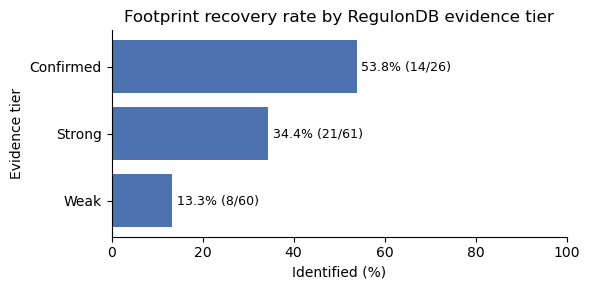

In [20]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 3))

plot_order = df_tier_stats.iloc[::-1]  # Confirmed on top
bars = ax.barh(plot_order["evidence_tier"], plot_order["pct_identified"], color="#4C72B0")

for bar, (_, row) in zip(bars, plot_order.iterrows()):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{row['pct_identified']:.1f}% ({row['n_identified']}/{row['n_total']})",
        va="center", fontsize=9,
    )

ax.set_xlabel("Identified (%)")
ax.set_ylabel("Evidence tier")
ax.set_xlim(0, 100)
ax.set_title("Footprint recovery rate by RegulonDB evidence tier")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

### Aside: does recovery get worse at densely-annotated promoters?

Bucket promoters by how many binding sites they have annotated and compare identification rate.

In [21]:
per_promoter = df_testable.groupby("Promoter").agg(
    n_sites=("TF", "size"),
    n_identified=("Category", lambda s: (s == "identified").sum()),
)
per_promoter["pct_identified"] = 100 * per_promoter["n_identified"] / per_promoter["n_sites"]
per_promoter["bucket"] = pd.cut(per_promoter["n_sites"], bins=[0, 1, 2, 3, 100], labels=["1", "2", "3", "4+"])

bucket_stats = per_promoter.groupby("bucket", observed=True).agg(
    n_promoters=("n_sites", "size"), total_sites=("n_sites", "sum"), total_identified=("n_identified", "sum")
)
bucket_stats["pct_identified"] = 100 * bucket_stats["total_identified"] / bucket_stats["total_sites"]
bucket_stats

,n_promoters,total_sites,total_identified,pct_identified
bucket,,,,
1,20,20,9,45.000000
2,10,20,7,35.000000
3,9,27,9,33.333333
4+,12,80,18,22.500000


## Recovery by transcription factor

Break `df_testable` down per TF to see which regulators we recover reliably and which we consistently miss. Split by number of annotated sites first: a TF with only 1-2 sites gives too little signal to call a real strength or weakness (one miss looks identical to bad luck), so keep those separate from the TFs with enough sites (>=3) to actually trust the percentage.

In [22]:
per_tf = df_testable.groupby("TF").agg(
    n_sites=("Promoter", "size"),
    n_identified=("Category", lambda s: (s == "identified").sum()),
)
per_tf["pct_identified"] = 100 * per_tf["n_identified"] / per_tf["n_sites"]

MIN_SITES_FOR_SIGNAL = 3
tf_reliable = per_tf[per_tf["n_sites"] >= MIN_SITES_FOR_SIGNAL].sort_values("pct_identified", ascending=False)
tf_low_n = per_tf[per_tf["n_sites"] < MIN_SITES_FOR_SIGNAL].sort_values(["pct_identified", "n_sites"], ascending=[False, False])

print(f"TFs with >= {MIN_SITES_FOR_SIGNAL} sites (trustworthy signal): {len(tf_reliable)}")
print(f"TFs with < {MIN_SITES_FOR_SIGNAL} sites (too little data to judge): {len(tf_low_n)}")
tf_reliable

TFs with >= 3 sites (trustworthy signal): 22
TFs with < 3 sites (too little data to judge): 20


,n_sites,n_identified,pct_identified
TF,,,
XylR,4,4,100.000000
LexA,7,6,85.714286
Rob,3,2,66.666667
CRP,17,9,52.941176
AraC,4,2,50.000000
RelBE,4,2,50.000000
MarA,6,2,33.333333
GalR,3,1,33.333333
GalS,3,1,33.333333


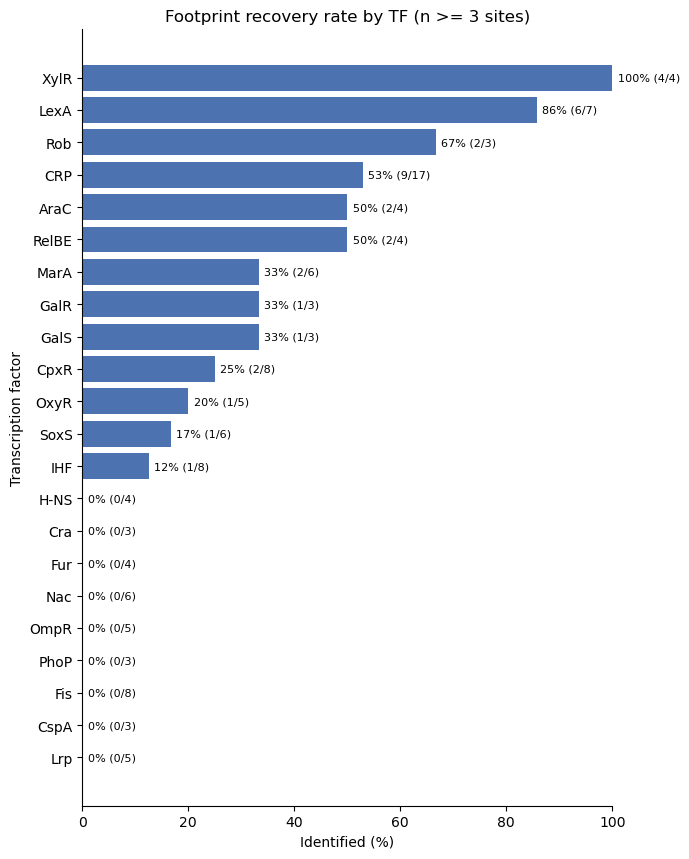

In [23]:
fig, ax = plt.subplots(figsize=(7, 0.35 * len(tf_reliable) + 1))

plot_order = tf_reliable.iloc[::-1]  # best performers on top
bars = ax.barh(plot_order.index, plot_order["pct_identified"], color="#4C72B0")

for bar, (_, row) in zip(bars, plot_order.iterrows()):
    ax.text(
        bar.get_width() + 1, bar.get_y() + bar.get_height() / 2,
        f"{row['pct_identified']:.0f}% ({row['n_identified']:.0f}/{row['n_sites']:.0f})",
        va="center", fontsize=8,
    )

ax.set_xlabel("Identified (%)")
ax.set_ylabel("Transcription factor")
ax.set_xlim(0, 100)
ax.set_title(f"Footprint recovery rate by TF (n >= {MIN_SITES_FOR_SIGNAL} sites)")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

TFs with fewer than 3 annotated sites, kept separate rather than folded into the ranking above — for review, not for drawing strength/weakness conclusions from.

In [24]:
tf_low_n

,n_sites,n_identified,pct_identified
TF,,,
RelB,2,2,100.0
CusR,1,1,100.0
DgoR,1,1,100.0
DicA,1,1,100.0
YdfH,1,1,100.0
AcrR,2,1,50.0
MarR,2,1,50.0
MprA,2,1,50.0
ArcA,2,0,0.0


## Success story: isolated activator sites

Hypothesis from the CRP breakdown: we recover binding sites more reliably when the TF acts as an **activator** and the site is **relatively isolated** (few other annotated sites at the same promoter). Test both dimensions on CRP alone (the motivating case) and on the whole dataset (to check it's not just a CRP artifact of small numbers).

In [25]:
df_testable = df_testable.copy()
df_testable["function_norm"] = df_testable["Function"].apply(lambda f: "dual" if "," in str(f) else f)
df_testable["identified"] = df_testable["Category"] == "identified"

promoter_density = df_testable.groupby("Promoter").size().rename("n_at_promoter")
df_testable = df_testable.merge(promoter_density, on="Promoter")
df_testable["density_bucket"] = pd.cut(
    df_testable["n_at_promoter"], bins=[0, 2, 4, 100], labels=["Isolated (1-2)", "Medium (3-4)", "Crowded (5+)"]
)

crp_breakdown = df_testable[df_testable["TF"] == "CRP"].groupby(
    ["function_norm", "density_bucket"], observed=True
)["identified"].agg(n_identified="sum", n_sites="size")
crp_breakdown["pct_identified"] = 100 * crp_breakdown["n_identified"] / crp_breakdown["n_sites"]
crp_breakdown

n_identified  n_sites  pct_identified
function_norm density_bucket                                       
activator     Isolated (1-2)             5        6       83.333333
              Medium (3-4)               2        3       66.666667
              Crowded (5+)               1        6       16.666667
repressor     Medium (3-4)               1        2       50.000000

In [26]:
all_breakdown = df_testable[df_testable["function_norm"].isin(["activator", "repressor"])].groupby(
    ["function_norm", "density_bucket"], observed=True
)["identified"].agg(n_identified="sum", n_sites="size")
all_breakdown["pct_identified"] = 100 * all_breakdown["n_identified"] / all_breakdown["n_sites"]
all_breakdown

n_identified  n_sites  pct_identified
function_norm density_bucket                                       
activator     Isolated (1-2)             7       17       41.176471
              Medium (3-4)               8       21       38.095238
              Crowded (5+)               6       28       21.428571
repressor     Isolated (1-2)             9       22       40.909091
              Medium (3-4)               2       13       15.384615
              Crowded (5+)              10       44       22.727273

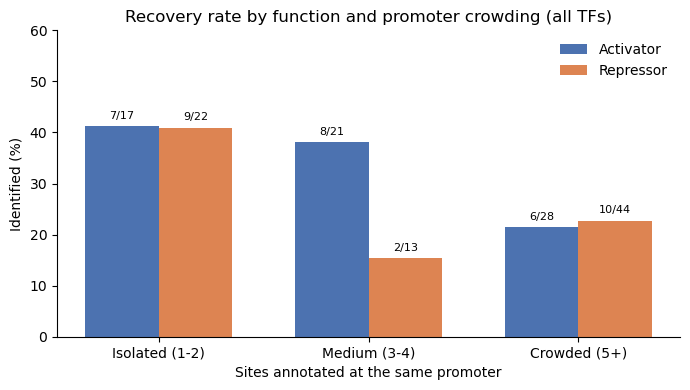

In [27]:
DENSITY_ORDER = ["Isolated (1-2)", "Medium (3-4)", "Crowded (5+)"]
plot_df = all_breakdown.reset_index().pivot(index="density_bucket", columns="function_norm", values="pct_identified").loc[DENSITY_ORDER]
counts_df = all_breakdown.reset_index().pivot(index="density_bucket", columns="function_norm", values="n_sites").loc[DENSITY_ORDER]
identified_df = all_breakdown.reset_index().pivot(index="density_bucket", columns="function_norm", values="n_identified").loc[DENSITY_ORDER]

fig, ax = plt.subplots(figsize=(7, 4))
x = range(len(DENSITY_ORDER))
width = 0.35

bars_act = ax.bar([i - width / 2 for i in x], plot_df["activator"], width, label="Activator", color="#4C72B0")
bars_rep = ax.bar([i + width / 2 for i in x], plot_df["repressor"], width, label="Repressor", color="#DD8452")

for bars, func in [(bars_act, "activator"), (bars_rep, "repressor")]:
    for bar, density in zip(bars, DENSITY_ORDER):
        n_id = identified_df.loc[density, func]
        n_tot = counts_df.loc[density, func]
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{n_id:.0f}/{n_tot:.0f}", ha="center", fontsize=8,
        )

ax.set_xticks(list(x))
ax.set_xticklabels(DENSITY_ORDER)
ax.set_ylabel("Identified (%)")
ax.set_xlabel("Sites annotated at the same promoter")
ax.set_ylim(0, 60)
ax.set_title("Recovery rate by function and promoter crowding (all TFs)")
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()

### Is the crowding effect just a confidence-tier proxy?

Crowded promoters could simply carry more low-confidence (W) annotations, in which case "crowding hurts" would really just be "weak evidence hurts." Check the confidence-tier mix per density bucket, then look at the crowding effect *within* each tier separately.

In [28]:
# confidence-tier mix per density bucket -- rules out "crowded == mostly W-tier" as the explanation
pd.crosstab(df_testable["density_bucket"], df_testable["Confidence"])

Confidence,C,S,W
density_bucket,,,
Isolated (1-2),4,16,20
Medium (3-4),8,10,17
Crowded (5+),14,35,23


In [29]:
confidence_density = df_testable.groupby(["Confidence", "density_bucket"], observed=True)["identified"].agg(
    n_identified="sum", n_sites="size"
)
confidence_density["pct_identified"] = 100 * confidence_density["n_identified"] / confidence_density["n_sites"]
confidence_density

n_identified  n_sites  pct_identified
Confidence density_bucket                                       
C          Isolated (1-2)             3        4       75.000000
           Medium (3-4)               5        8       62.500000
           Crowded (5+)               6       14       42.857143
S          Isolated (1-2)            10       16       62.500000
           Medium (3-4)               2       10       20.000000
           Crowded (5+)               9       35       25.714286
W          Isolated (1-2)             3       20       15.000000
           Medium (3-4)               4       17       23.529412
           Crowded (5+)               1       23        4.347826

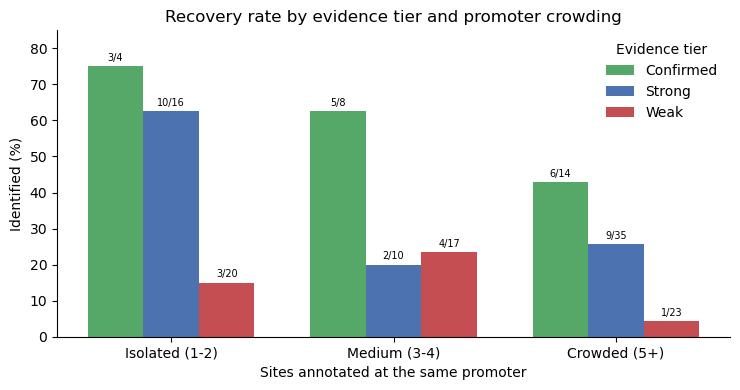

In [30]:
TIER_COLORS = {"C": "#55A868", "S": "#4C72B0", "W": "#C44E52"}
TIER_LABELS = {"C": "Confirmed", "S": "Strong", "W": "Weak"}

pct_df = confidence_density["pct_identified"].unstack("Confidence").loc[DENSITY_ORDER]
n_id_df = confidence_density["n_identified"].unstack("Confidence").loc[DENSITY_ORDER]
n_tot_df = confidence_density["n_sites"].unstack("Confidence").loc[DENSITY_ORDER]

fig, ax = plt.subplots(figsize=(7.5, 4))
x = range(len(DENSITY_ORDER))
width = 0.25
offsets = {"C": -width, "S": 0, "W": width}

for tier in ["C", "S", "W"]:
    bars = ax.bar(
        [i + offsets[tier] for i in x], pct_df[tier], width,
        label=TIER_LABELS[tier], color=TIER_COLORS[tier],
    )
    for bar, density in zip(bars, DENSITY_ORDER):
        ax.text(
            bar.get_x() + bar.get_width() / 2, bar.get_height() + 1.5,
            f"{n_id_df.loc[density, tier]:.0f}/{n_tot_df.loc[density, tier]:.0f}",
            ha="center", fontsize=7,
        )

ax.set_xticks(list(x))
ax.set_xticklabels(DENSITY_ORDER)
ax.set_ylabel("Identified (%)")
ax.set_xlabel("Sites annotated at the same promoter")
ax.set_ylim(0, 85)
ax.set_title("Recovery rate by evidence tier and promoter crowding")
ax.legend(frameon=False, title="Evidence tier")
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()